In [40]:
# STEP 1 Analyse the data and pre-processing
import numpy as np  
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset 
DATA_DIR = "C:/Users/anton/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1"
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

selected_files = [
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"
]
df_list = []

for file in csv_files:
    full_path = os.path.join(DATA_DIR, file)
    print(f"Chargement : {file}")
    df_tmp = pd.read_csv(full_path, low_memory=False)
    df_list.append(df_tmp)

for i, data in enumerate(df_list, start=1):
    rows, cols = data.shape
    print(f'df{i} -> {rows} rows, {cols} columns')
    
data = pd.concat(df_list,axis=0, ignore_index=True)

for df in df_list: del df

#Data Overview 
print("---first 5 rows:---")
print(data.head())
print("\n---Info about the dataset ---")
print(data.info())
print("\n--- describe statistics ---")
print(data.describe())

Fichiers trouvés : ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']
Chargement : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Morning.pcap_ISCX.csv
Chargement : Monday-WorkingHours.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Chargement : Tuesday-WorkingHours.pcap_ISCX.csv
Chargement : Wednesday-workingHours.pcap_ISCX.csv
df1 -> 225745 rows, 79 columns
df2 -> 286467 rows, 79 columns
df3 -> 191033 rows, 79 columns
df4 -> 529918 rows, 79 column

In [41]:
data.sample(n=10, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,50545,232,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,31226,2,2,68,380,34,34,34.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,80,99951883,9,7,317,11595,317,0,35.222222,105.666667,...,32,999.0,0.0,999,999,99900000.0,0.0,99900000,99900000,DoS Hulk
699389,53,30894,4,2,140,172,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,53,48943,2,2,88,166,44,44,44.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
800686,53,23728,1,1,56,84,56,56,56.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1434488,23,3,2,0,4,0,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1968368,80,141,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
934343,443,229,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
693547,443,176084,10,8,559,5437,192,0,55.900000,78.196974,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [42]:
# Checking for missing values
missing_values = data.isna().sum()
missing_percentage = (missing_values / len(data)) * 100

# Printing columns with missing values
for column, count in missing_values.items():
    if count != 0:
        print(f"Column '{column}' has {count} missing values, which is {missing_percentage[column]:.2f}% of the total")

Column 'Flow Bytes/s' has 1358 missing values, which is 0.05% of the total


In [43]:
# Removal of leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

In [44]:
# Checking and counting duplicates
duplicates = data.duplicated()
duplicate_count = duplicates.sum()

# Output results
print(f"Number of duplicate rows: {duplicate_count}")

# Removal of duplicates
data = data.drop_duplicates(keep='first')
del duplicates
data.shape

Number of duplicate rows: 308381


(2522362, 79)

In [45]:
#Identify columns with identical data
identical_columns = {}
columns = data.columns
list_control = columns.copy().tolist()

# Compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

# Print the result
if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


In [46]:
# Removing the columns with duplicated values
for key, value in identical_columns.items():
    data.drop(columns=value, inplace=True)
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [47]:
# Checking for infinite values
num_columns = data.select_dtypes(include = np.number).columns
has_infinite = np.isinf(data[num_columns]).sum()
print(has_infinite[has_infinite > 0])
# Treating infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [48]:
# Attack counts
attack_counts = data['Label'].value_counts().reset_index()
attack_counts.columns = ['Attack Type', 'Number of Occurrences']

# Duplicating the df and dropping rows with missing values
data_no_na = data.dropna()

# Counting the total number of occurrences of each attack after dropping
occurrences_nonull = data_no_na['Label'].value_counts().reset_index()
occurrences_nonull.columns = ['Attack Type', 'Occurrences w/o Null Rows']

# Merging the DataFrames
attack_counts = attack_counts.merge(occurrences_nonull, on='Attack Type', how='left')

# Calculating the difference
attack_counts['Abs Difference'] = attack_counts['Number of Occurrences'] - attack_counts['Occurrences w/o Null Rows']
attack_counts['Difference %'] = ((attack_counts['Abs Difference'] * 100) / attack_counts['Number of Occurrences']).round(2)

# Visualization
attack_counts

,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


In [49]:
# Cleaning up
del data_no_na

# Evaluating percentage of missing values per column
threshold = 10
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Filter columns with missing values over the threshold
high_missing_cols = missing_percentage[missing_percentage > threshold]

# Print columns with high missing percentages
if len(high_missing_cols) > 0:
    print(f'The following columns have over {threshold}% of missing values:')
    print(high_missing_cols)
else:
    print('There are no columns with missing values greater than the threshold')

There are no columns with missing values greater than the threshold


In [50]:
# Dropping missing values
data = data.dropna()
print(f'Dataset shape after row-wise removal: {data.shape}')

Dataset shape after row-wise removal: (2520798, 67)


In [51]:
# Check for numeric columns that contain only a single unique value, indicating no diversity in values.
# Such columns contribute no useful information to the analysis and may be candidates for removal.
only_unique_cols = []
for col in data.columns:
    if len(data[col].unique()) == 1:
        only_unique_cols.append(col)
        print(col)

print(f'\nThe number of columns with only one unique values is: {len(only_unique_cols)}')

Bwd PSH Flags

The number of columns with only one unique values is: 1


In [52]:
# Dropping the columns with only one unique value
data.drop(only_unique_cols, axis=1, inplace=True)
del only_unique_cols


In [53]:
# Checking the new shape after cleaning
data.shape

(2520798, 66)

In [54]:
# Mapping the attacks to the new group
group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'DoS GoldenEye': 'DoS',
    'FTP-Patator': 'Brute Force',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Infiltration': 'Infiltration',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}

# Map to new group column
data['Attack Type'] = data['Label'].map(group_mapping)

In [55]:
# Checking the new values
data['Attack Type'].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Infiltration           36
Miscellaneous          11
Name: count, dtype: int64

In [56]:
# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

In [58]:
#Removing rows with statistically irrelevant attack types
data.drop(data[(data['Attack Type'] == 'Infiltration') | (data['Attack Type'] == 'Miscellaneous')].index, inplace=True)

In [60]:
# Data shape and attack counts after removal
print(data.shape)
data['Attack Type'].value_counts()

(2520751, 66)


Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

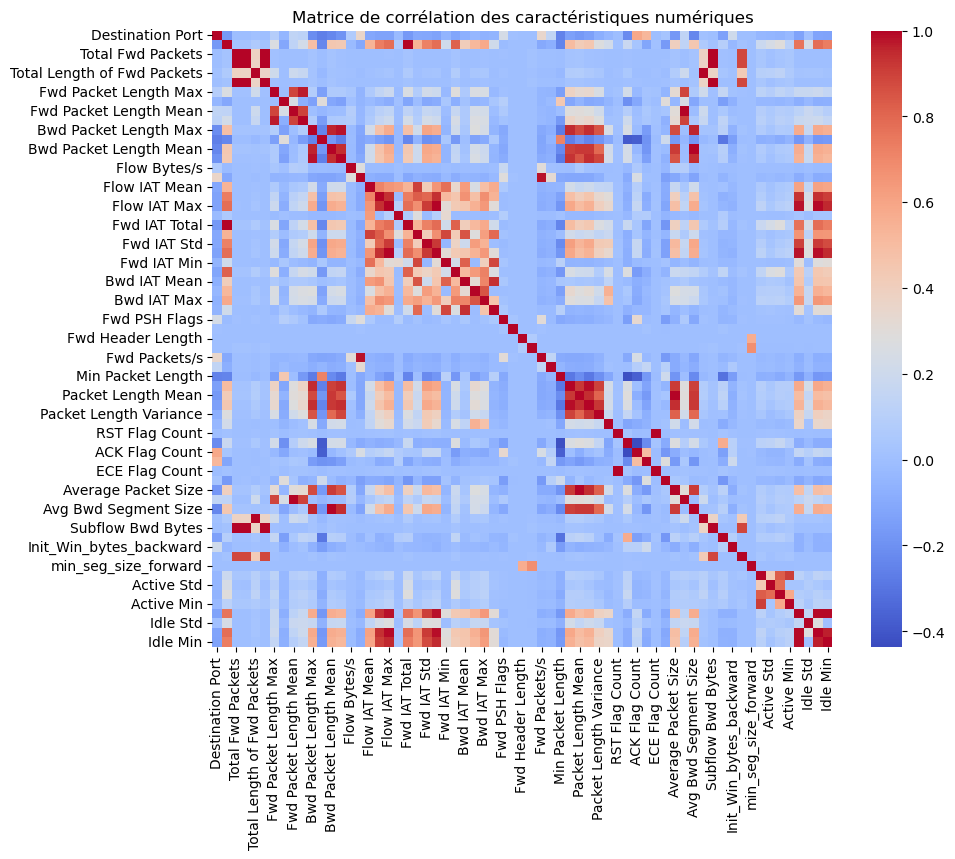


Caractéristiques redondantes identifiées par forte corrélation (> 0.95): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']
(2520751, 48)


In [66]:
# Calculating the correlation matrix
numeric_df = data.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation des caractéristiques numériques")
plt.show()

# Identification of pairs of highly correlated features
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"\nCaractéristiques redondantes identifiées par forte corrélation (> 0.95): {to_drop}")

# You can decide to delete these columns (Data Reduction)
data.drop(columns=to_drop, inplace=True)
print(data.shape)


Class distribution :
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


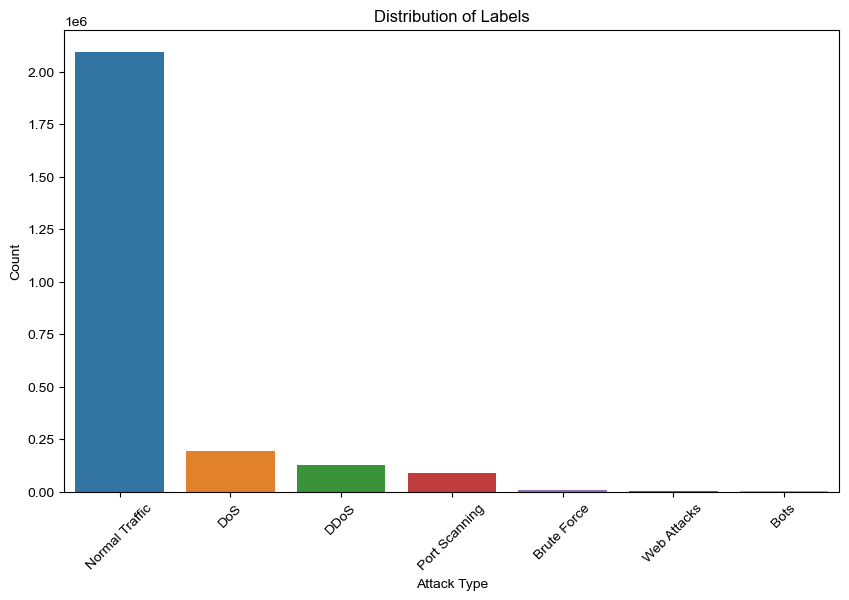


Ratio Majority/Minority : 4.92
--> Level of imbalance: weak (1:2-1:0), technique needed -> use class weight=balanced


In [70]:
df = data
# Problem formalization 
TARGET_COLUMN = 'Attack Type'
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# analyzing imbalancing data
class_counts = y.value_counts()
print("\nClass distribution :")
print(class_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
sns.set_theme()
plt.title('Distribution of Labels')
plt.ylabel('Count')
plt.xlabel('Attack Type')
plt.xticks(rotation=45)
plt.show()

ratio = class_counts.max() / (len(y)-class_counts.max())

print(f"\nRatio Majority/Minority : {ratio:.2f}")

if ratio >= 100:
    print("--> Level of imbalance: severe (> 100), technique needed -> hybrid sampling")
elif ratio >= 10 and ratio < 50:
    print("--> Level of imbalance: moderate (1:10-1:50 ), technique needed -> oversampling or SMOTE")
else:
    print("--> Level of imbalance: weak (1:2-1:0), technique needed -> use class weight=balanced")

In [76]:
# Normalisation/Standardisation

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Identifier les colonnes numériques et nominales
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist() 
# Assurez-vous d'exclure la colonne cible ! 
if TARGET_COLUMN in numeric_features: numeric_features.remove(TARGET_COLUMN)

numeric_transformer = Pipeline(steps=[
    # Étape 1: Imputation des NaNs (résultat de la conversion de np.inf en np.nan)
    ('imputer', SimpleImputer(strategy='mean')), 
    # Étape 2: Standardisation des données propres
    ('scaler', StandardScaler())
])

# Définir les étapes de pré-traitement dans un ColumnTransformer [2, 5]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features), # Standardisation (z-score) [38]
    ],
    remainder='drop' # Conserver les autres colonnes non traitées (par ex. les colonnes à supprimer)
)

# Vous utiliserez ce préprocesseur dans un pipeline pour le modèle de base (Étape 4 du projet)
# Note : Pour la Phase 1, il est souvent suffisant de définir les étapes de nettoyage et de transformation.
print("# Normalisation/Standardisation")

# Normalisation/Standardisation



           RÉSULTATS D'ÉVALUATION DU BASELINE
Accuracy du Baseline : 0.9121
F1-score du Baseline (Weighted) : 0.9323
--------------------------------------------------

RAPPORT DE CLASSIFICATION (average='weighted') :

                precision    recall  f1-score   support

          Bots     0.0348    0.9932    0.0672       584
   Brute Force     0.8088    1.0000    0.8943      2745
          DDoS     0.4872    1.0000    0.6552     38404
           DoS     0.9816    0.8973    0.9376     58124
Normal Traffic     0.9981    0.9070    0.9504    628518
 Port Scanning     0.9411    0.9280    0.9345     27208
   Web Attacks     0.0946    0.9191    0.1716       643

      accuracy                         0.9121    756226
     macro avg     0.6209    0.9492    0.6587    756226
  weighted avg     0.9667    0.9121    0.9323    756226

--------------------------------------------------

MATRICE DE CONFUSION :

[[   580      0      0      0      4      0      0]
 [     0   2745      0      0    

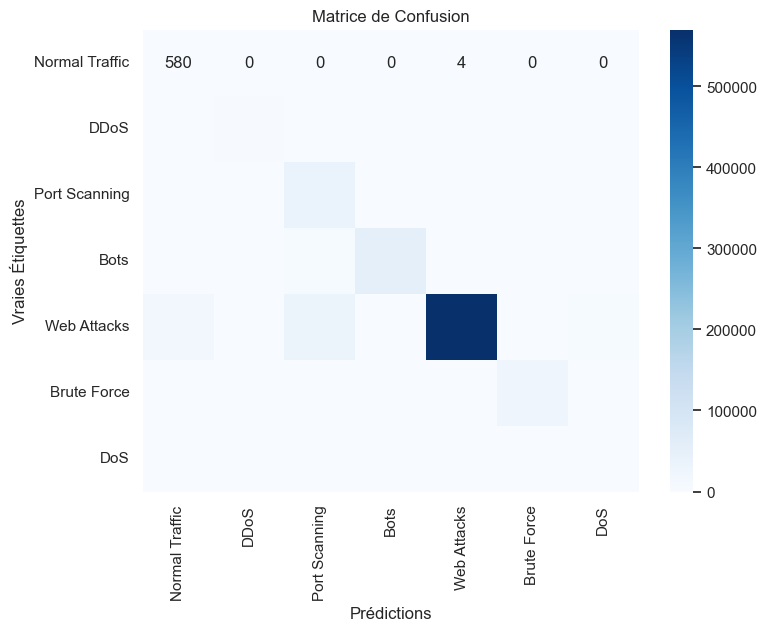


AUC-ROC Score (One-vs-Rest, Weighted) : 0.9736


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Séparer les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Créer le modèle de base (Arbre de Décision)
# Utilisez class_weight='balanced' pour compenser le déséquilibre 
baseline_model = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')

# Utiliser un Pipeline pour combiner le pré-traitement et le modèle de base
full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', baseline_model)])

# Entraîner et évaluer (cette partie sera plus détaillée dans la Phase 2)
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)

# --- ÉTAPE 2: ÉVALUATION AVEC MÉTRIQUES ROBUSTES ---

print("\n" + "="*50)
print("           RÉSULTATS D'ÉVALUATION DU BASELINE")
print("="*50)

# 1. Métriques de Base (Accuracy et F1-score pondéré)
print(f"Accuracy du Baseline : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score du Baseline (Weighted) : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("-" * 50)
# 2. Precision, Recall, et F1-score Détaillés (Rapport de Classification)
# 'weighted': utile pour une métrique de performance globale pondérée par la taille des classes.
# 'macro': utile pour garantir que le modèle est bon sur chaque classe, sans être biaisé par la majorité.
print("\nRAPPORT DE CLASSIFICATION (average='weighted') :\n")
print(classification_report(y_test, y_pred, digits=4))
print("-" * 50)

# 3. Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
class_labels = y.unique()
print("\nMATRICE DE CONFUSION :\n")
# Affichage simple de la matrice
print(cm)

# Pour une meilleure visualisation (Nécessite matplotlib et seaborn)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vraies Étiquettes')
plt.show()

# 4. AUC (Area Under the Curve)
# Pour le multiclasse, on utilise la stratégie One-vs-Rest (ovr) ou One-vs-One (ovo).
# 'ovr' et 'weighted' sont couramment utilisés pour un score résumé.
try:
    auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    print(f"\nAUC-ROC Score (One-vs-Rest, Weighted) : {auc_score:.4f}")
except ValueError as e:
    # Ceci peut arriver si une seule classe est présente dans y_test (rare avec stratify)
    print(f"\nImpossible de calculer l'AUC multiclasse : {e}")

print("="*50)


In [80]:
# --- ÉTAPE 3 : OPTIMISATION DES HYPERPARAMÈTRES (GRID SEARCH) ---
from sklearn.model_selection import GridSearchCV

# 1. Définir la grille des hyperparamètres à tester
# Note : On utilise le préfixe 'classifier__' car le modèle est dans un Pipeline
param_grid = {
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_split': [2, 10, 50],
    'classifier__criterion': ['gini', 'entropy']
}

# 2. Création de l'objet GridSearchCV
# n_jobs=-1 utilise tous les cœurs du processeur pour aller plus vite
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=2)

# 3. Exécution du Grid Search
# ASTUCE : Pour gagner du temps, on fait le GridSearch sur un échantillon (ex: 10% ou 50k lignes)
# Si vous avez un ordinateur très puissant, vous pouvez utiliser tout X_train
X_train_sample = X_train.sample(n=50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print("Démarrage du Grid Search sur un échantillon...")
grid_search.fit(X_train_sample, y_train_sample)

# 4. Récupération du meilleur modèle
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")
print(f"Meilleur score F1 (validation croisée) : {grid_search.best_score_:.4f}")

# On réentraîne le meilleur modèle sur TOUT le jeu d'entraînement
best_dt_model = grid_search.best_estimator_
print("\nRéentraînement du meilleur modèle sur tout le dataset...")
best_dt_model.fit(X_train, y_train)

Démarrage du Grid Search sur un échantillon...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres trouvés : {'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__min_samples_split': 2}
Meilleur score F1 (validation croisée) : 0.9966

Réentraînement du meilleur modèle sur tout le dataset...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Destination Port',
                                                   'Flow Duration',
                                                   'Total Fwd Packets',
                                                   'Total Length of Fwd '
                                                   'Packets',
                                                   'Fwd Packet Length Max',
                                                   'Fwd Packet Length Min',
                                                   'Fwd Packet Length Mean',
                                                   'Bwd Packet Length Max',
                                                   'Bwd Packet Length Min',
                                                   'Flow Bytes/s',
                                                   'Flow...
                                                   'Flow IAT Min',
                                                   'Fwd IAT Mean',
                                                   'Fwd IAT Std', 'Fwd IAT Min',
                                                   'Bwd IAT Total',
                                                   'Bwd IAT Mean',
                                                   'Bwd IAT Std', 'Bwd IAT Max',
                                                   'Bwd IAT Min',
                                                   'Fwd PSH Flags',
                                                   'Fwd URG Flags',
                                                   'Fwd Header Length',
                                                   'Bwd Header Length',
                                                   'Bwd Packets/s',
                                                   'Min Packet Length',
                                                   'Max Packet Length', ...])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=15,
                                        random_state=42))])

In [82]:
# --- ÉTAPE 4 : ENSEMBLE LEARNING ---
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# --- A. BAGGING ---
# On utilise l'arbre optimisé comme base pour le Bagging
# On doit extraire le classifieur du pipeline pour le passer au Bagging
tree_classifier = best_dt_model.named_steps['classifier']

# Création du Bagging dans un pipeline pour inclure le préprocesseur
bagging_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BaggingClassifier(estimator=tree_classifier, 
                                     n_estimators=10, 
                                     random_state=42, 
                                     n_jobs=-1))
])

print("Entraînement du modèle Bagging...")
bagging_model.fit(X_train, y_train)


# --- B. VOTING (Hybride) ---
# Nous allons combiner l'Arbre de Décision avec une Régression Logistique
# La Régression Logistique est un bon complément car elle est linéaire.

# Modèle 1 : L'arbre optimisé (déjà prêt dans best_dt_model)
# Modèle 2 : Régression Logistique
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', multi_class='auto', max_iter=1000, n_jobs=-1))
])

# Création du Voting Classifier (Soft voting utilise les probabilités)
voting_model = VotingClassifier(
    estimators=[
        ('optimized_dt', best_dt_model),
        ('log_reg', log_reg)
    ],
    voting='soft',
    n_jobs=-1
)

print("Entraînement du modèle Voting...")
voting_model.fit(X_train, y_train)

Entraînement du modèle Bagging...
Entraînement du modèle Voting...


VotingClassifier(estimators=[('optimized_dt',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('imputer',
                                                                                                 SimpleImputer()),
                                                                                                ('scaler',
                                                                                                 StandardScaler())]),
                                                                                ['Destination '
                                                                                 'Port',
                                                                                 'Flow '
                                                                                 'Duration',
                                                                                 'Total '
                                                                                 'Fwd '
                                                                                 'Packets',
                                                                                 'Total '
                                                                                 'Length '
                                                                                 'of '
                                                                                 'Fwd '
                                                                                 'Packets',
                                                                                 'Fwd '
                                                                                 'Packet '
                                                                                 'Length '
                                                                                 'Max',
                                                                                 'Fwd '
                                                                                 'Packet '
                                                                                 'Length '
                                                                                 'Min',
                                                                                 'Fwd '
                                                                                 'Packet...
                                                                                 'Fwd '
                                                                                 'IAT '
                                                                                 'Std',
                                                                                 'Fwd '
                                                                                 'IAT '
                                                                                 'Min',
                                                                                 'Bwd '
                                                                                 'IAT '
                                                                                 'Total',
                                                                                 'Bwd '
                                                                                 'IAT '
                                                                                 'Mean',
                                                                                 'Bwd '
                                                                                 'IAT '
                                                                                 'Std',
                                                    


--- Résultats Comparatifs ---
Baseline DT -> Accuracy: 0.9121, F1-Score: 0.9323
Optimized DT -> Accuracy: 0.9978, F1-Score: 0.9981
Bagging DT -> Accuracy: 0.9990, F1-Score: 0.9990
Voting (DT+LR) -> Accuracy: 0.9989, F1-Score: 0.9989


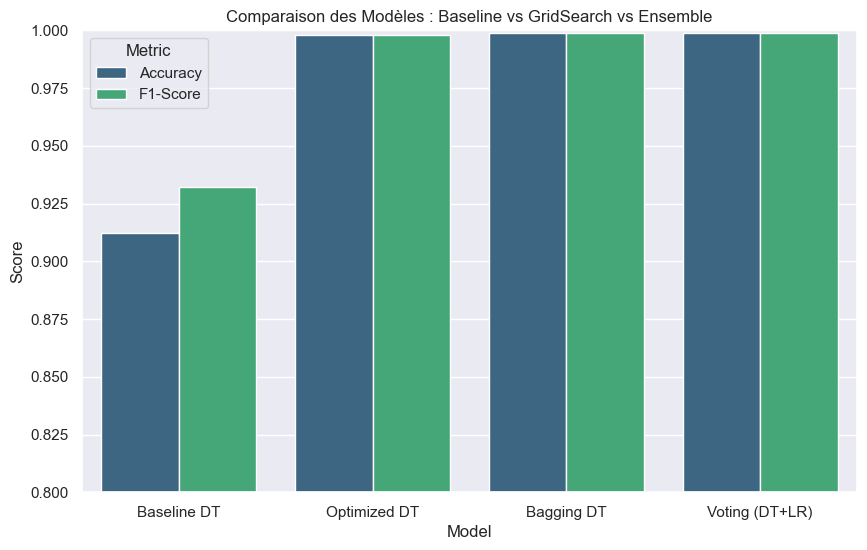


Matrice de confusion du meilleur modèle : Bagging DT

RAPPORT DE CLASSIFICATION (average='weighted') :

                precision    recall  f1-score   support

          Bots     0.6949    0.9709    0.8100       584
   Brute Force     1.0000    0.9982    0.9991      2745
          DDoS     0.9993    0.9998    0.9996     38404
           DoS     0.9978    0.9996    0.9987     58124
Normal Traffic     0.9999    0.9989    0.9994    628518
 Port Scanning     0.9891    0.9993    0.9942     27208
   Web Attacks     0.9577    0.9860    0.9716       643

      accuracy                         0.9990    756226
     macro avg     0.9484    0.9932    0.9675    756226
  weighted avg     0.9991    0.9990    0.9990    756226

--------------------------------------------------
[[   567      0      0      0     17      0      0]
 [     0   2740      0      0      4      1      0]
 [     0      0  38396      0      8      0      0]
 [     0      0      0  58103     16      4      1]
 [   249      0  

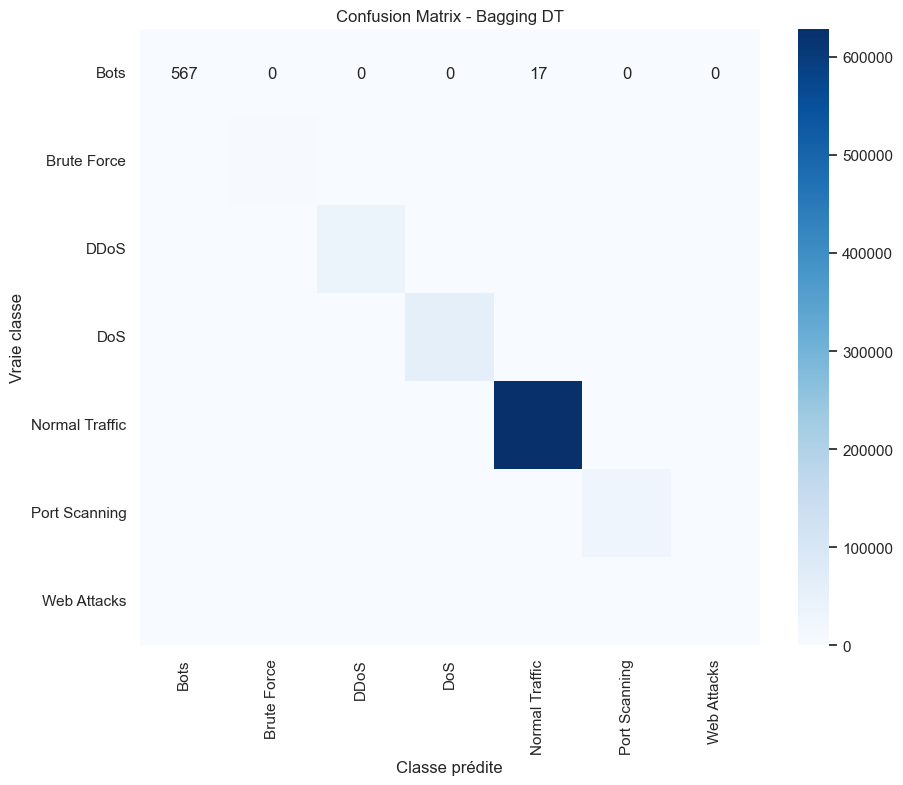

In [88]:
# --- ÉTAPE 5 : ÉVALUATION COMPARATIVE ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# Liste des modèles à évaluer
models = {
    "Baseline DT": full_pipeline, # Le modèle initial (s'il est encore en mémoire)
    "Optimized DT": best_dt_model,
    "Bagging DT": bagging_model,
    "Voting (DT+LR)": voting_model
}

results = []

print("\n--- Résultats Comparatifs ---")
for name, model in models.items():
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})
    print(f"{name} -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

# Création d'un DataFrame pour l'affichage
results_df = pd.DataFrame(results)

# --- VISUALISATION ---

# 1. Barplot des performances
plt.figure(figsize=(10, 6))
# Transformation pour affichage (melt)
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Comparaison des Modèles : Baseline vs GridSearch vs Ensemble")
plt.ylim(0.8, 1.0) # Zoomer sur le haut du graphique pour voir les différences
plt.ylabel("Score")
plt.show()

# 2. Matrice de confusion du meilleur modèle (par exemple le Voting ou le Bagging)
from sklearn.metrics import confusion_matrix

best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
print(f"\nMatrice de confusion du meilleur modèle : {best_model_name}")

best_model_instance = models[best_model_name]
y_pred_best = best_model_instance.predict(X_test)

print("\nRAPPORT DE CLASSIFICATION (average='weighted') :\n")
print(classification_report(y_test, y_pred_best, digits=4))
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_best)
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model_instance.classes_, 
            yticklabels=best_model_instance.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.show()